In [81]:
import pickle
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch

with open('../data/unsw_node_map.pkl', 'rb') as f:
    nm = pickle.load(f)

id_to_node = {v:k for k,v in nm.items()}

weights = torch.load('../pretrained/static/unsw/rw_bert_unsw_tiny-best.pt')

/tmp/ipykernel_2061156/1830325001.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load('../pretrained/static/unsw/rw_bert_unsw_tiny-best.pt')


In [82]:
tokens = weights['bert.embeddings.word_embeddings.weight']
node_embs = tokens[1:50]
labels = [id_to_node[i].split('.')[0] for i in range(1,50)]

In [83]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(node_embs.cpu())

tsne = TSNE(n_components=2)
x_tsne = tsne.fit_transform(node_embs.cpu())

/tmp/ipykernel_2061156/526243602.py:2: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  codes, categories = pd.factorize(labels)


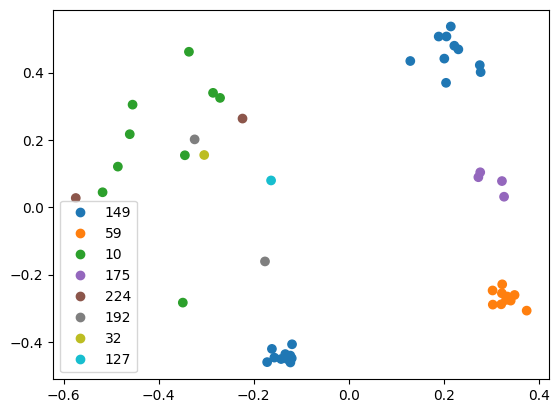

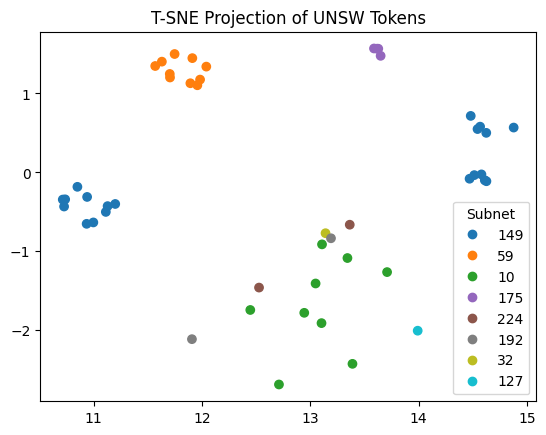

In [84]:
import pandas as pd
codes, categories = pd.factorize(labels)

scatter = plt.scatter(x_pca[:,1], x_pca[:,0], c=codes, cmap='tab10')
plt.legend(handles=scatter.legend_elements()[0], labels=list(categories))
plt.show()

scatter = plt.scatter(x_tsne[:,0], x_tsne[:,1], c=codes, cmap='tab10')
plt.legend(title='Subnet', handles=scatter.legend_elements()[0], labels=list(categories))
plt.title('T-SNE Projection of UNSW Tokens')
plt.show()

In [85]:
print(codes)
print(categories)

[0 1 0 1 0 1 0 1 0 0 2 1 2 1 1 1 3 0 3 0 3 0 1 0 1 0 0 0 0 0 0 0 3 0 2 4 2
 0 0 5 2 4 6 2 7 2 5 2 2]
['149' '59' '10' '175' '224' '192' '32' '127']


In [86]:
import numpy as np
categories = np.array(codes)
should_eval = (categories == 0 ) + (categories == 1) + (categories == 3)

n2v = torch.load('../data/unsw_n2v.pt')

x_idx = torch.arange(1,50)[should_eval]
y = categories[should_eval]
y[y==3] = 2

node_embs = node_embs.cpu()
n2v = n2v.cpu()

/tmp/ipykernel_2061156/4175956167.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  n2v = torch.load('../data/unsw_n2v.pt')


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

def compare():
    tr_size = int(0.8*x_idx.size(0))
    tr_idx = torch.randperm(x_idx.size(0))[:tr_size]
    te_idx = torch.randperm(x_idx.size(0))[tr_size:]

    tr_x_fm = node_embs[x_idx[tr_idx]]
    te_x_fm = node_embs[x_idx[te_idx]]

    tr_x_n2v = n2v[x_idx[tr_idx]]
    te_x_n2v = n2v[x_idx[te_idx]]

    tr_y = y[tr_idx]
    te_y = y[te_idx]

    mlp = MLPClassifier()
    mlp.fit(tr_x_fm, tr_y)
    y_fm = mlp.predict(te_x_fm)
    acc_fm  = accuracy_score(te_y, y_fm)

    mlp = MLPClassifier()
    mlp.fit(tr_x_n2v, tr_y)
    y_n2v = mlp.predict(te_x_n2v)
    acc_n2v = accuracy_score(te_y, y_n2v)

    return acc_fm, acc_n2v

outs = [compare() for _ in range(10)]
df = pd.DataFrame(outs)
df.mean()

/mnt/raid10/isaiah/miniconda3/envs/lnm/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/raid10/isaiah/miniconda3/envs/lnm/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/raid10/isaiah/miniconda3/envs/lnm/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/mnt/raid10/isaiah/miniconda3/envs/lnm/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't conv

0    0.957143
1    0.885714
dtype: float64

In [89]:
df.sem()

0    0.021822
1    0.019048
dtype: float64